In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns


# Training on 40X data without preprocessing

In [9]:
train_dir = "Final-40X/train"
val_dir   = "Final-40X/val"
test_dir  = "Final-40X/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


Found 2866 files belonging to 2 classes.
Found 410 files belonging to 2 classes.
Found 819 files belonging to 2 classes.


In [10]:
base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224,224,3))
base.trainable = False   

In [11]:
x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base.input, outputs=output)

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 72s 797ms/step - accuracy: 0.9051 - loss: 0.2866 - val_accuracy: 0.9122 - val_loss: 0.2383
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 68s 756ms/step - accuracy: 0.9182 - loss: 0.2384 - val_accuracy: 0.9268 - val_loss: 0.2099
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 67s 744ms/step - accuracy: 0.9217 - loss: 0.2183 - val_accuracy: 0.9390 - val_loss: 0.1928
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 67s 740ms/step - accuracy: 0.9337 - loss: 0.1988 - val_accuracy: 0.9390 - val_loss: 0.1777
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 66s 731ms/step - accuracy: 0.9336 - loss: 0.1873 - val_accuracy: 0.9439 - val_loss: 0.1681


In [15]:
base.trainable = True   # unfreeze entire EfficientNet-B0

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # smaller LR for fine-tuning
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 382s 4s/step - accuracy: 0.7613 - loss: 0.5225 - val_accuracy: 0.9073 - val_loss: 0.2400
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 351s 4s/step - accuracy: 0.8586 - loss: 0.3349 - val_accuracy: 0.9098 - val_loss: 0.2393
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 353s 4s/step - accuracy: 0.9012 - loss: 0.2641 - val_accuracy: 0.9220 - val_loss: 0.2114
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 377s 4s/step - accuracy: 0.9179 - loss: 0.2079 - val_accuracy: 0.9293 - val_loss: 0.1836
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 399s 4s/step - accuracy: 0.9324 - loss: 0.1884 - val_accuracy: 0.9415 - val_loss: 0.1586


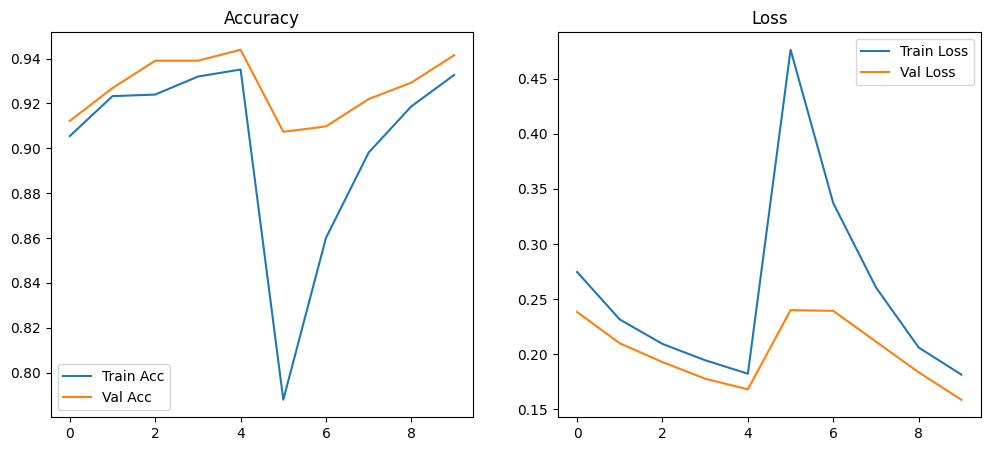

In [16]:
def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']

    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label="Train Acc")
    plt.plot(epochs_range, val_acc, label="Val Acc")
    plt.legend(); plt.title("Accuracy")

    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.legend(); plt.title("Loss")

    plt.show()

plot_history(history, history_finetune)


In [17]:
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

y_pred = model.predict(test_ds)
y_pred_class = (y_pred > 0.5).astype("int32")


26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 709ms/step


In [18]:
print(classification_report(y_true, y_pred_class, target_names=["benign", "malignant"]))


              precision    recall  f1-score   support

      benign       0.98      0.92      0.95       405
   malignant       0.93      0.98      0.95       414

    accuracy                           0.95       819
   macro avg       0.95      0.95      0.95       819
weighted avg       0.95      0.95      0.95       819



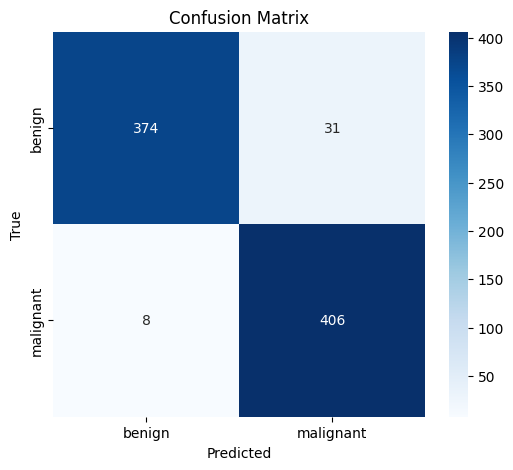

In [19]:
cm = confusion_matrix(y_true, y_pred_class)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


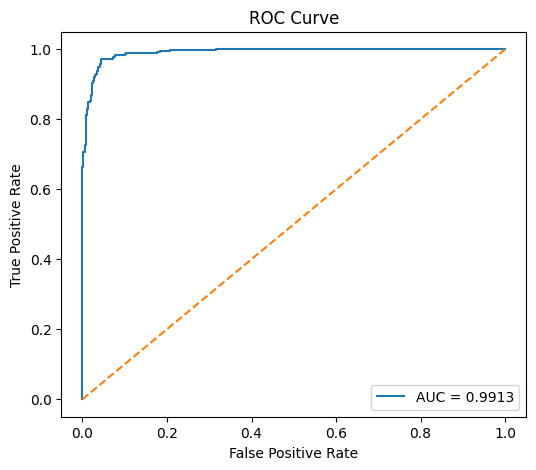

In [20]:
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [22]:
model.save("efficientnet_b0_40X.h5")


# Training on 100X data without preprocessing

In [23]:
train_dir = "Final-100X/train"
val_dir   = "Final-100X/val"
test_dir  = "Final-100X/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


Found 2925 files belonging to 2 classes.
Found 421 files belonging to 2 classes.
Found 835 files belonging to 2 classes.


In [24]:
base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224,224,3))
base.trainable = False   

In [25]:
x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model2 = Model(inputs=base.input, outputs=output)

model2.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [27]:
history = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 72s 785ms/step - accuracy: 0.8816 - loss: 0.3602 - val_accuracy: 0.8860 - val_loss: 0.3039
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 69s 751ms/step - accuracy: 0.8938 - loss: 0.2994 - val_accuracy: 0.8931 - val_loss: 0.2624
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 69s 755ms/step - accuracy: 0.9114 - loss: 0.2513 - val_accuracy: 0.9026 - val_loss: 0.2375
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 69s 755ms/step - accuracy: 0.9195 - loss: 0.2270 - val_accuracy: 0.9121 - val_loss: 0.2212
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 70s 758ms/step - accuracy: 0.9203 - loss: 0.2139 - val_accuracy: 0.9216 - val_loss: 0.2105


In [29]:
base.trainable = True   # unfreeze entire EfficientNet-B0

model2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # smaller LR for fine-tuning
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 386s 4s/step - accuracy: 0.8755 - loss: 0.3128 - val_accuracy: 0.9145 - val_loss: 0.2174
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 364s 4s/step - accuracy: 0.9094 - loss: 0.2328 - val_accuracy: 0.9240 - val_loss: 0.1850
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 349s 4s/step - accuracy: 0.9160 - loss: 0.2111 - val_accuracy: 0.9382 - val_loss: 0.1630
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 333s 4s/step - accuracy: 0.9258 - loss: 0.1789 - val_accuracy: 0.9454 - val_loss: 0.1435
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 334s 4s/step - accuracy: 0.9444 - loss: 0.1548 - val_accuracy: 0.9477 - val_loss: 0.1284


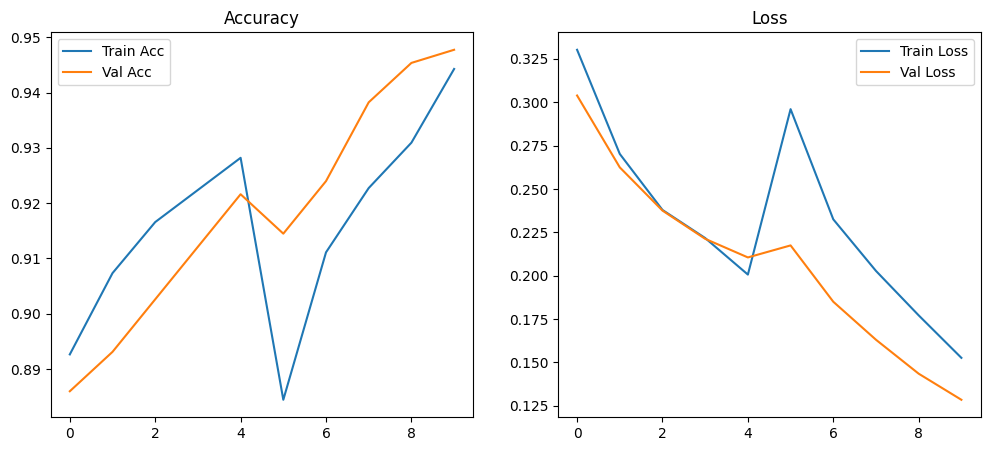

In [30]:
def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']

    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label="Train Acc")
    plt.plot(epochs_range, val_acc, label="Val Acc")
    plt.legend(); plt.title("Accuracy")

    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.legend(); plt.title("Loss")

    plt.show()

plot_history(history, history_finetune)


In [44]:
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

y_pred = model2.predict(test_ds)
y_pred_class = (y_pred > 0.5).astype("int32")


26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 673ms/step


In [45]:
print(classification_report(y_true, y_pred_class, target_names=["benign", "malignant"]))


              precision    recall  f1-score   support

      benign       0.99      0.83      0.90       404
   malignant       0.86      0.99      0.92       418

    accuracy                           0.91       822
   macro avg       0.92      0.91      0.91       822
weighted avg       0.92      0.91      0.91       822



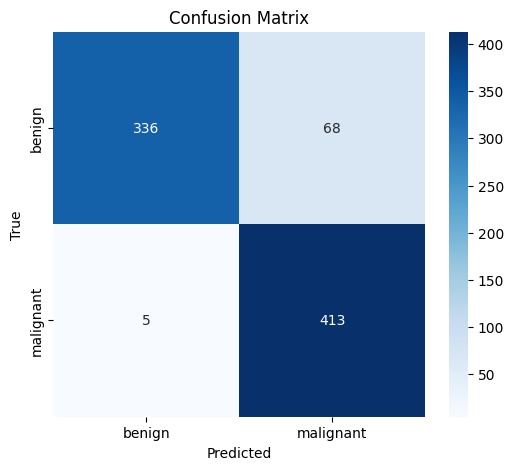

In [46]:
cm = confusion_matrix(y_true, y_pred_class)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


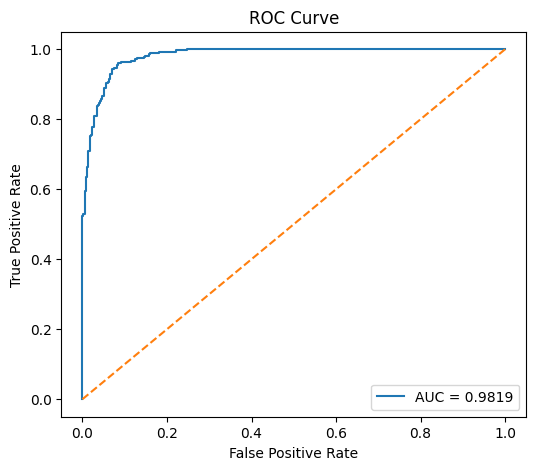

In [47]:
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [48]:
model2.save("efficientnet_b0_100X.h5")


# Training on 200X dataset 

In [36]:
train_dir = "Final-200X/train"
val_dir   = "Final-200X/val"
test_dir  = "Final-200X/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


Found 2879 files belonging to 2 classes.
Found 412 files belonging to 2 classes.
Found 822 files belonging to 2 classes.


In [37]:
base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224,224,3))
base.trainable = False   

In [38]:
x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model3 = Model(inputs=base.input, outputs=output)

model3.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [40]:
history = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 80s 820ms/step - accuracy: 0.7161 - loss: 0.5536 - val_accuracy: 0.8956 - val_loss: 0.3166
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 70s 779ms/step - accuracy: 0.8873 - loss: 0.3244 - val_accuracy: 0.9175 - val_loss: 0.2567
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 70s 784ms/step - accuracy: 0.9059 - loss: 0.2776 - val_accuracy: 0.9248 - val_loss: 0.2276
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 69s 772ms/step - accuracy: 0.9200 - loss: 0.2375 - val_accuracy: 0.9272 - val_loss: 0.2107
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 65s 726ms/step - accuracy: 0.9180 - loss: 0.2348 - val_accuracy: 0.9272 - val_loss: 0.1982


In [41]:
base.trainable = True  

model3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.7289 - loss: 0.5495 - val_accuracy: 0.8981 - val_loss: 0.2637
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 330s 4s/step - accuracy: 0.8296 - loss: 0.3813 - val_accuracy: 0.9029 - val_loss: 0.2509
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 329s 4s/step - accuracy: 0.8885 - loss: 0.2851 - val_accuracy: 0.9078 - val_loss: 0.2191
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.8943 - loss: 0.2605 - val_accuracy: 0.9272 - val_loss: 0.1936
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.9292 - loss: 0.2050 - val_accuracy: 0.9320 - val_loss: 0.1753


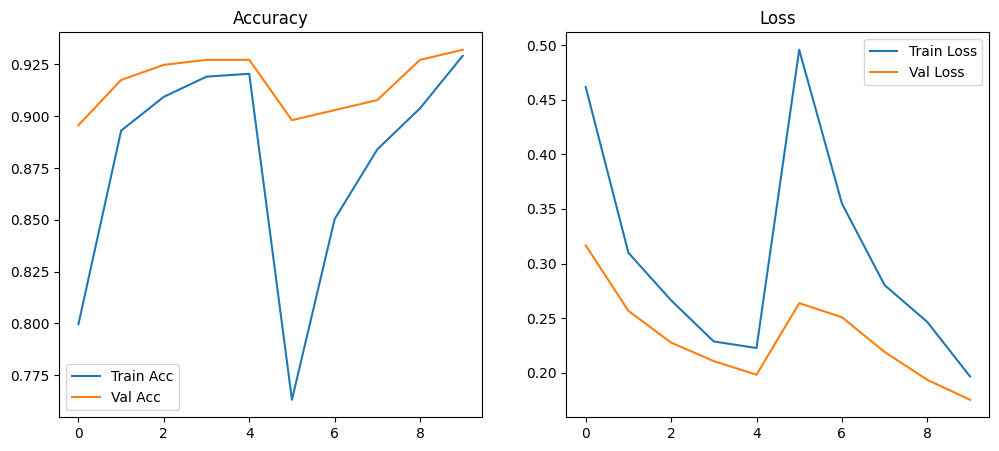

In [42]:
def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']

    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label="Train Acc")
    plt.plot(epochs_range, val_acc, label="Val Acc")
    plt.legend(); plt.title("Accuracy")

    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.legend(); plt.title("Loss")

    plt.show()

plot_history(history, history_finetune)


In [49]:
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

y_pred = model3.predict(test_ds)
y_pred_class = (y_pred > 0.5).astype("int32")


26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 632ms/step


In [50]:
print(classification_report(y_true, y_pred_class, target_names=["benign", "malignant"]))


              precision    recall  f1-score   support

      benign       0.98      0.92      0.95       404
   malignant       0.93      0.98      0.95       418

    accuracy                           0.95       822
   macro avg       0.95      0.95      0.95       822
weighted avg       0.95      0.95      0.95       822



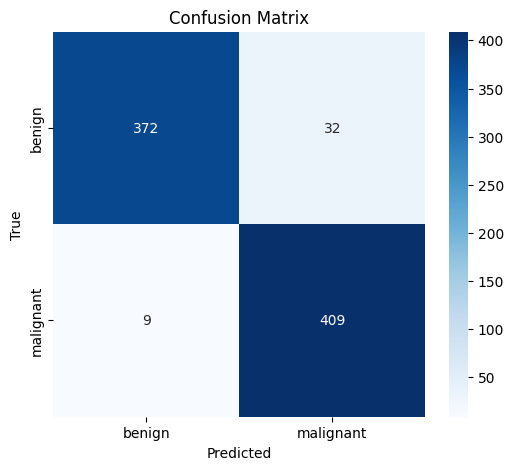

In [51]:
cm = confusion_matrix(y_true, y_pred_class)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


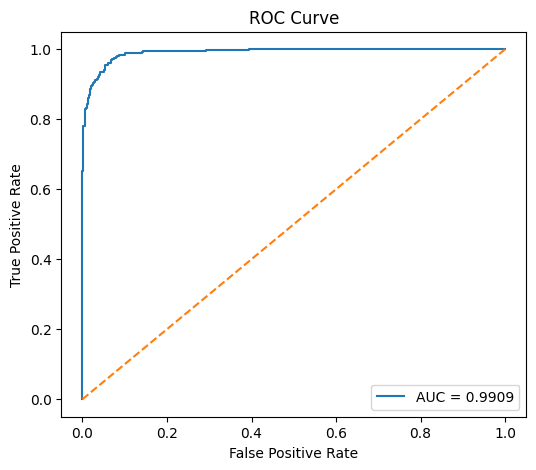

In [52]:
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [53]:
model3.save("efficientnet_b0_200X.h5")


# Training on 400X dataset 

In [54]:
train_dir = "Final-400X/train"
val_dir   = "Final-400X/val"
test_dir  = "Final-400X/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


Found 2743 files belonging to 2 classes.
Found 394 files belonging to 2 classes.
Found 783 files belonging to 2 classes.


In [55]:
base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224,224,3))
base.trainable = False   

In [56]:
x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model4 = Model(inputs=base.input, outputs=output)

model4.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [57]:
history = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 79s 836ms/step - accuracy: 0.7496 - loss: 0.5222 - val_accuracy: 0.8680 - val_loss: 0.3619
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 749ms/step - accuracy: 0.8802 - loss: 0.3420 - val_accuracy: 0.9036 - val_loss: 0.3006
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 745ms/step - accuracy: 0.8912 - loss: 0.2900 - val_accuracy: 0.9086 - val_loss: 0.2709
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 65s 759ms/step - accuracy: 0.9023 - loss: 0.2606 - val_accuracy: 0.9112 - val_loss: 0.2554
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 750ms/step - accuracy: 0.9062 - loss: 0.2476 - val_accuracy: 0.9162 - val_loss: 0.2444


In [58]:
base.trainable = True  

model4.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 356s 4s/step - accuracy: 0.7113 - loss: 0.5725 - val_accuracy: 0.8832 - val_loss: 0.3167
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 346s 4s/step - accuracy: 0.8286 - loss: 0.3929 - val_accuracy: 0.8934 - val_loss: 0.2837
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 366s 4s/step - accuracy: 0.8840 - loss: 0.3018 - val_accuracy: 0.9137 - val_loss: 0.2405
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 375s 4s/step - accuracy: 0.8921 - loss: 0.2543 - val_accuracy: 0.9188 - val_loss: 0.2159
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 366s 4s/step - accuracy: 0.9048 - loss: 0.2354 - val_accuracy: 0.9239 - val_loss: 0.1984


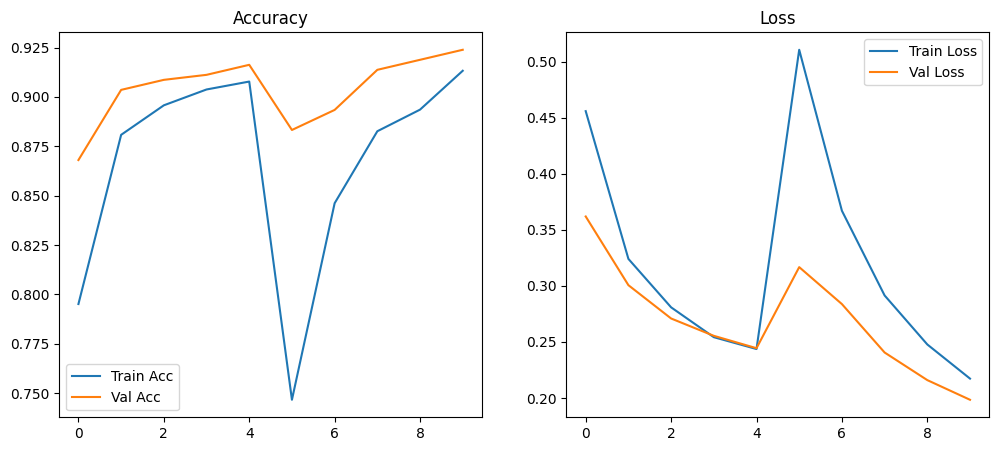

In [59]:
def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']

    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label="Train Acc")
    plt.plot(epochs_range, val_acc, label="Val Acc")
    plt.legend(); plt.title("Accuracy")

    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.legend(); plt.title("Loss")

    plt.show()

plot_history(history, history_finetune)


In [60]:
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

y_pred = model4.predict(test_ds)
y_pred_class = (y_pred > 0.5).astype("int32")


25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 771ms/step


In [61]:
print(classification_report(y_true, y_pred_class, target_names=["benign", "malignant"]))


              precision    recall  f1-score   support

      benign       0.96      0.91      0.93       397
   malignant       0.91      0.96      0.93       386

    accuracy                           0.93       783
   macro avg       0.93      0.93      0.93       783
weighted avg       0.93      0.93      0.93       783



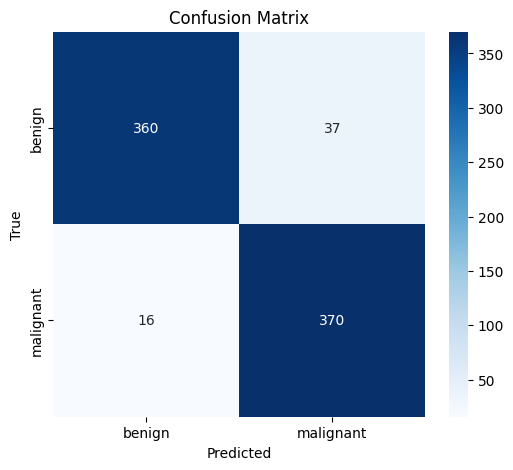

In [62]:
cm = confusion_matrix(y_true, y_pred_class)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


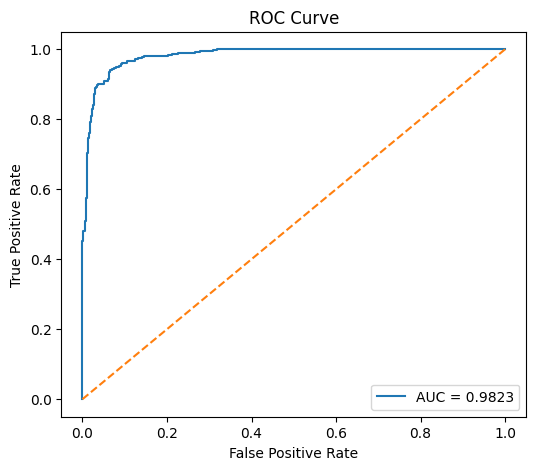

In [63]:
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
